# First-order system: the infinite horizon vs a long finite horizon

The model is the canonical declared first-order system from
[`models/first_order.py`](models/first_order.py): see the module for its
construction. Two cases of the same model. Case 1 runs five sampling steps
with the infinite-horizon terminal segment (`drto.infinite_horizon`) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.first_order import first_order
from plotting import plot_states, plot_controls

m1 = first_order(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpsw9q_gk5.pyomo.nl...
pounce: wrote C:\

Parsed 91 vars, 76 cons, jac_nnz=338, h_nnz=40 in 0.03s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:      318
Number of nonzeros in inequality constraint Jacobian.:       20
Number of nonzeros in Lagrangian Hessian.............:       40

Total number of variables............................:       91
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       20
                     variables with only upper bounds:        0
Total number of equality constraints.................:       72
Total number of inequality constraints...............:        4
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        4
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg)

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 76, 'Number of variables': 91, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 1.2502379417419434}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
seg = m1.drto_infinite_horizon
print(f"first move   : u = {pyo.value(m1.u[0]):.5f}")
print(f"tail endpoint: z = {pyo.value(seg.z[1]):.5f}   (setpoint {pyo.value(m1.z_ss):.5f})")
drto.info(m1)

first move   : u = 0.59878
tail endpoint: z = 0.50000   (setpoint 0.50000)


horizon,"t (ContinuousSet, 16 points)"
states,z (free)
dynamics,dzdt[k] == (- z[k] + u[k])/tau_p for k in t
controls,"u (piecewise_constant, free)"
tracking stage cost,cost[k] == 10*(z[k] - z_ss)**2 + (u[k] - u_ss)**2 for k in OrderedScalarSet
terminal cost,term == 10*(z[5] - z_ss)**2
initial conditions,z[0] == z_hat
steady-state targets,z_ss (of z)
steady-state control targets,u_ss (of u)
cost_group,drto_infinite_horizon


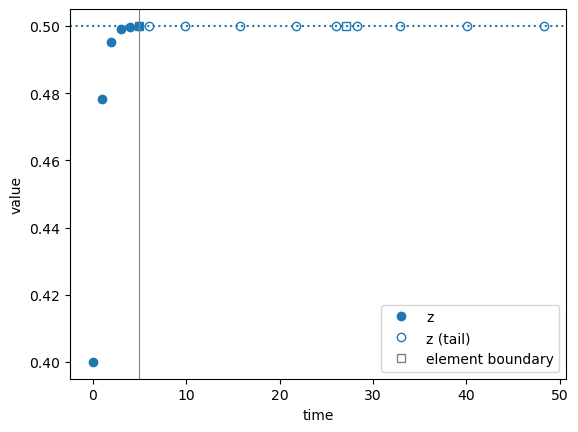

In [3]:
plot_states(m1)

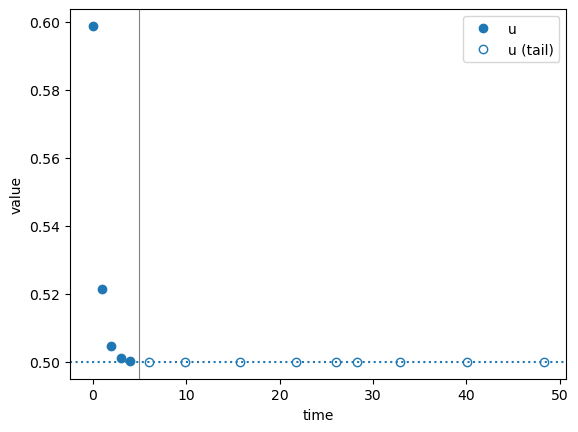

In [4]:
plot_controls(m1)

## Case 2: fifty samples, finite horizon with the terminal cost

In [5]:
m2 = first_order(N=50)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpzkavb5dn.pyomo.nl...
pounce: wrote C:\

Parsed 403 vars, 353 cons, jac_nnz=1356, h_nnz=101 in 0.03s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:     1356
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      101

Total number of variables............................:      403
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       50
                     variables with only upper bounds:        0
Total number of equality constraints.................:      353
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 353, 'Number of variables': 403, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 1.2389287948608398}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [6]:
print(f"first move: u = {pyo.value(m2.u[0]):.5f}")
drto.info(m2)

first move: u = 0.59878


horizon,"t (ContinuousSet, 151 points)"
states,z (free)
dynamics,dzdt[k] == (- z[k] + u[k])/tau_p for k in t
controls,"u (piecewise_constant, free)"
tracking stage cost,cost[k] == 10*(z[k] - z_ss)**2 + (u[k] - u_ss)**2 for k in OrderedScalarSet
terminal cost,term == 10*(z[50] - z_ss)**2
initial conditions,z[0] == z_hat
steady-state targets,z_ss (of z)
steady-state control targets,u_ss (of u)


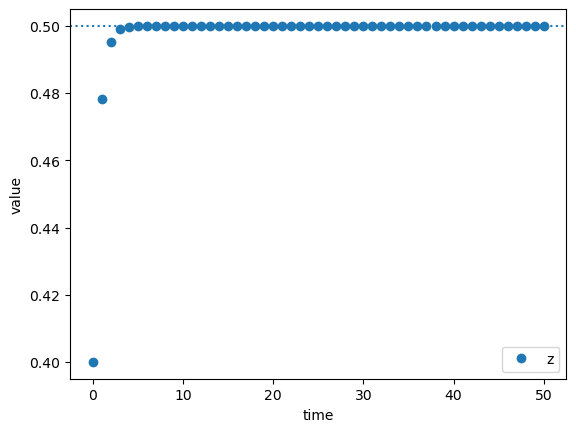

In [7]:
plot_states(m2)

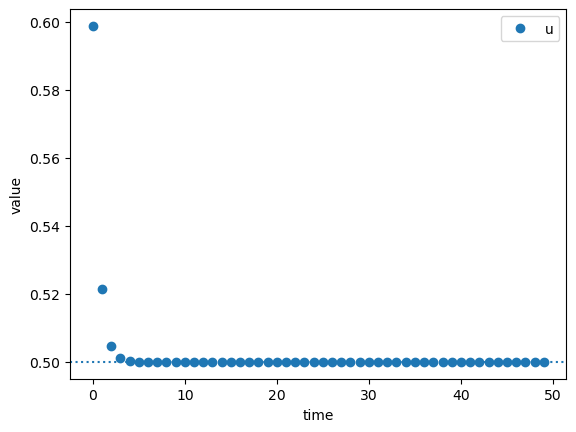

In [8]:
plot_controls(m2)